In [1]:
# pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


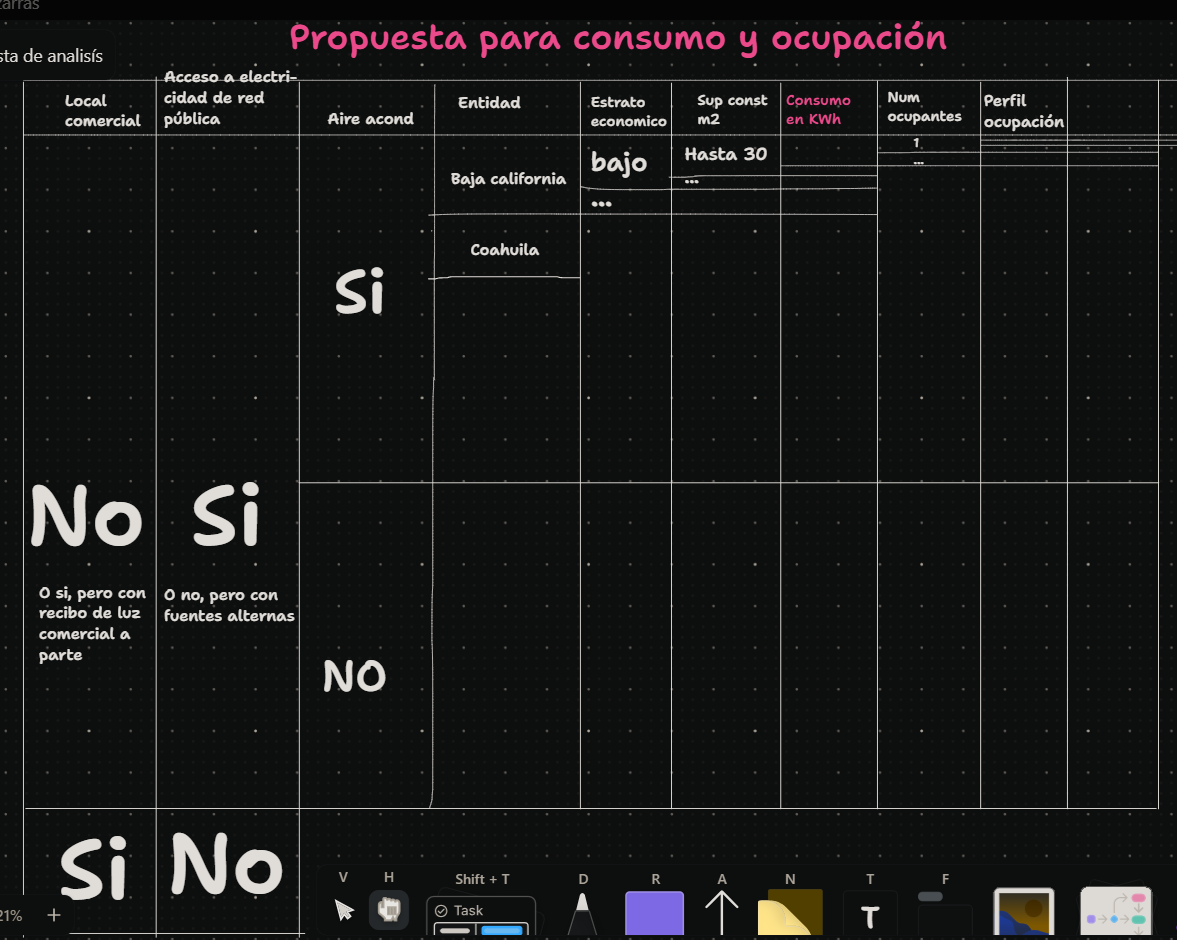

Las variables que necesitamos son:

**De ENCEVI** 
- "folio"
- local comercial
    - "local_com"
        - 1 = Si
        - 2 = No
    - Recibo de luz del local "elect_loc"
        - 1 = Si
        - 2 = No
- Electricidad de red pública "electri"
    - 1 = Si
    - 2 = No
- Uso de aire acondicionado "uso_aire"
    - 1 = Si
    - 2 = No
- super_cons  
    - 1 = Hasta 30m²  
    - 2 = De 31 a 55m²  
    - 3 = De 56 a 75m²  
    - 4 = De 76 a 100m²  
    - 5 = De 101 a 150m²  
    - 6 = De 151 a 200m²  
    - 7 = 201 a más m²  
    - 9 = No sabe

**De VIVIENDA:**
- "folio"
- Factor de expansión semestral "factor_sem"
- Entidad "entidad"
    - Son 32 entidad, una por cada estado
- Estrato socioeconómico "est_socio"
    - 1 = Bajo
    - 2 = Medio bajo
    - 3 = Medio alto
    - 4 = Alto

**De HOGAR:**
- "folio"
- Número de integrantes del hogar "tot_integ"

**De CONSUMO:**
- folio "folioviv"
- Factor de expansión semestral "factor"
- Consumo en el perdiodo en kWh "bill_kwh_estimation"
- Periodo "bill_period"
    - bi-monthly
    - monthly	

## Datos que se tiraron

In [3]:
f = "../data/ENCEVI_raw/3_encevi_2018_base_de_datos_csv/vivienda.csv"
VIVIENDA = pd.read_csv(f, 
                       usecols = ["folio","est_socio","factor_sem","region"]
                      )
# print(f[46:])  #Es para imprimir el nombre del archivo 
VIVIENDA

,folio,est_socio,factor_sem,region
0,1,3,373,2
1,2,3,373,2
2,3,3,373,2
3,4,3,373,2
4,5,3,373,2
...,...,...,...,...
28948,28949,2,382,2
28949,28950,2,382,2
28950,28951,2,382,2
28951,28952,2,382,2


In [4]:
f = "../data/ENCEVI_Hernandez/encevi_result_db_041722.csv"
CONSUMO = pd.read_csv(f,
                     usecols = ["folioviv","factor","bill_kwh_estimation","bill_days","munic_name"]
                    )
CONSUMO.rename(columns={"folioviv": "folio",
                        # "factor": "factor_sem"
                       }
               , inplace=True)

CONSUMO

,folio,factor,bill_days,munic_name,bill_kwh_estimation
0,1,373,62,Aguascalientes,113.802301
1,2,373,30,Aguascalientes,128.896444
2,3,373,30,Aguascalientes,228.645610
3,4,373,30,Aguascalientes,167.110992
4,5,373,30,Aguascalientes,207.517844
...,...,...,...,...,...
20573,28941,382,62,Tepetongo,156.404354
20574,28943,382,60,Tepetongo,41.689786
20575,28945,382,59,Tepetongo,77.180962
20576,28948,382,30,Tepetongo,245.776231


In [5]:
f = '../data/modificado/ENCEVI_VI_HO_CONSUMO.parquet'

ENCEVI_CONSUMO = pd.read_parquet(f)
# print(len(viv))
# viv.dropna(inplace=True)
ENCEVI_CONSUMO

,factor,bill_days,munic_name,bill_kwh_estimation,total_niv,super_ter,super_cons,tot_cuart,electri,local_com,elect_loc,uso_aire,est_socio,factor_sem,entidad,tot_integ
0,373,62,Aguascalientes,113.802301,2,3,7,11,1,2,<NA>,2,3,373,1,1
1,373,30,Aguascalientes,128.896444,1,3,3,6,1,2,<NA>,2,3,373,1,4
2,373,30,Aguascalientes,228.645610,2,3,7,5,1,2,<NA>,2,3,373,1,4
3,373,30,Aguascalientes,167.110992,1,3,4,6,1,2,<NA>,2,3,373,1,1
4,373,30,Aguascalientes,207.517844,1,3,4,5,1,2,<NA>,2,3,373,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20564,382,62,Tepetongo,156.404354,1,9,9,4,1,2,<NA>,2,2,382,32,5
20565,382,60,Tepetongo,41.689786,1,6,2,3,1,2,<NA>,2,2,382,32,4
20566,382,59,Tepetongo,77.180962,1,9,9,4,1,2,<NA>,2,2,382,32,5
20567,382,30,Tepetongo,245.776231,2,6,6,5,1,2,<NA>,2,2,382,32,5


In [6]:
f = '../data/modificado/ENCEVI_VI_HO.parquet'

ENCEVI = pd.read_parquet(f)
# print(len(viv))
# viv.dropna(inplace=True)
ENCEVI

,folio,total_niv,super_ter,super_cons,tot_cuart,electri,local_com,elect_loc,uso_aire,est_socio,factor_sem,entidad,tot_integ
0,1,2,3,7,11,1,2,<NA>,2,3,373,1,1
1,2,1,3,3,6,1,2,<NA>,2,3,373,1,4
2,3,2,3,7,5,1,2,<NA>,2,3,373,1,4
3,4,1,3,4,6,1,2,<NA>,2,3,373,1,1
4,5,1,3,4,5,1,2,<NA>,2,3,373,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28948,28949,1,9,9,3,1,2,<NA>,2,2,382,32,4
28949,28950,1,9,9,2,1,2,<NA>,2,2,382,32,3
28950,28951,1,9,9,5,1,2,<NA>,2,2,382,32,2
28951,28952,1,6,4,4,1,2,<NA>,2,2,382,32,4


In [7]:
total_viviendas = VIVIENDA["factor_sem"].sum()
print(f'En total hay {total_viviendas:,.0f} en la encuesta de la ENCEVI')

En total hay 33,162,148 en la encuesta de la ENCEVI


In [8]:
x = viviendas_ENCEVI_CONSUMO = ENCEVI_CONSUMO["factor_sem"].sum()
print(f"Se tiraron: {total_viviendas - x:,.0f} datos que equivalen al {round(100*(total_viviendas - x)/total_viviendas,2)} %")

Se tiraron: 10,837,910 datos que equivalen al 32.68 %


In [9]:
# pd.set_option('display.max_rows', None)

# # Contar y mostrar
# print(CONSUMO['munic_name'].value_counts())

In [10]:
ENCEVI

,folio,total_niv,super_ter,super_cons,tot_cuart,electri,local_com,elect_loc,uso_aire,est_socio,factor_sem,entidad,tot_integ
0,1,2,3,7,11,1,2,<NA>,2,3,373,1,1
1,2,1,3,3,6,1,2,<NA>,2,3,373,1,4
2,3,2,3,7,5,1,2,<NA>,2,3,373,1,4
3,4,1,3,4,6,1,2,<NA>,2,3,373,1,1
4,5,1,3,4,5,1,2,<NA>,2,3,373,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28948,28949,1,9,9,3,1,2,<NA>,2,2,382,32,4
28949,28950,1,9,9,2,1,2,<NA>,2,2,382,32,3
28950,28951,1,9,9,5,1,2,<NA>,2,2,382,32,2
28951,28952,1,6,4,4,1,2,<NA>,2,2,382,32,4


In [11]:
ENCEVI_CONSUMO.isna().sum()

factor                     0
bill_days                  0
munic_name                 0
bill_kwh_estimation       70
total_niv                  0
super_ter                  0
super_cons                 0
tot_cuart                  0
electri                    0
local_com                  0
elect_loc              19224
uso_aire                   0
est_socio                  0
factor_sem                 0
entidad                    0
tot_integ                  0
dtype: int64

In [12]:
ENCEVI_CONSUMO = ENCEVI_CONSUMO.dropna(subset=['bill_kwh_estimation']).copy()
ENCEVI_CONSUMO

,factor,bill_days,munic_name,bill_kwh_estimation,total_niv,super_ter,super_cons,tot_cuart,electri,local_com,elect_loc,uso_aire,est_socio,factor_sem,entidad,tot_integ
0,373,62,Aguascalientes,113.802301,2,3,7,11,1,2,<NA>,2,3,373,1,1
1,373,30,Aguascalientes,128.896444,1,3,3,6,1,2,<NA>,2,3,373,1,4
2,373,30,Aguascalientes,228.645610,2,3,7,5,1,2,<NA>,2,3,373,1,4
3,373,30,Aguascalientes,167.110992,1,3,4,6,1,2,<NA>,2,3,373,1,1
4,373,30,Aguascalientes,207.517844,1,3,4,5,1,2,<NA>,2,3,373,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20564,382,62,Tepetongo,156.404354,1,9,9,4,1,2,<NA>,2,2,382,32,5
20565,382,60,Tepetongo,41.689786,1,6,2,3,1,2,<NA>,2,2,382,32,4
20566,382,59,Tepetongo,77.180962,1,9,9,4,1,2,<NA>,2,2,382,32,5
20567,382,30,Tepetongo,245.776231,2,6,6,5,1,2,<NA>,2,2,382,32,5


In [13]:
ENCEVI_CONSUMO.isna().sum()

factor                     0
bill_days                  0
munic_name                 0
bill_kwh_estimation        0
total_niv                  0
super_ter                  0
super_cons                 0
tot_cuart                  0
electri                    0
local_com                  0
elect_loc              19169
uso_aire                   0
est_socio                  0
factor_sem                 0
entidad                    0
tot_integ                  0
dtype: int64

In [14]:
ENCEVI_CONSUMO["factor_sem"].sum()

np.int64(22250204)

In [15]:
22324238 - 22250204

74034

In [16]:
#Tiramos los que tiene local comercial
ENCEVI_CONSUMO = ENCEVI_CONSUMO[ENCEVI_CONSUMO["local_com"] != 1]
ENCEVI_CONSUMO["factor_sem"].sum()

np.int64(20884739)

In [17]:
22250204 - 20884739

1365465

In [18]:
ENCEVI_CONSUMO['elect_loc'].value_counts()

Series([], Name: count, dtype: Int64)

In [19]:
ENCEVI_CONSUMO.isna().sum()

factor                     0
bill_days                  0
munic_name                 0
bill_kwh_estimation        0
total_niv                  0
super_ter                  0
super_cons                 0
tot_cuart                  0
electri                    0
local_com                  0
elect_loc              19169
uso_aire                   0
est_socio                  0
factor_sem                 0
entidad                    0
tot_integ                  0
dtype: int64

In [20]:
x = viviendas_ENCEVI_CONSUMO = ENCEVI_CONSUMO["factor_sem"].sum()
print(f"Se tiraron: {total_viviendas - x:,.0f} datos que equivalen al {round(100*(total_viviendas - x)/total_viviendas,2)} %")

Se tiraron: 12,277,409 datos que equivalen al 37.02 %


## Mapeo

In [21]:
mapeo_m2 = {
    1: 30,
    2: 55,
    3: 75,
    4: 100,
    5: 150,
    6: 200,
    7: np.nan,
    9: np.nan
}

# Crear la nueva columna "m2" aplicando el diccionario de mapeo
ENCEVI_CONSUMO['m2'] = ENCEVI_CONSUMO['super_cons'].map(mapeo_m2)
ENCEVI_CONSUMO['kwh_mes'] = (ENCEVI_CONSUMO['bill_kwh_estimation'] / ENCEVI_CONSUMO['bill_days']) * 30
ENCEVI_CONSUMO['kwh_m2_mes'] = ENCEVI_CONSUMO['kwh_mes']/ENCEVI_CONSUMO['m2']
ENCEVI_CONSUMO

C:\Users\roele\AppData\Local\Temp\ipykernel_45200\4174376466.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ENCEVI_CONSUMO['m2'] = ENCEVI_CONSUMO['super_cons'].map(mapeo_m2)
C:\Users\roele\AppData\Local\Temp\ipykernel_45200\4174376466.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ENCEVI_CONSUMO['kwh_mes'] = (ENCEVI_CONSUMO['bill_kwh_estimation'] / ENCEVI_CONSUMO['bill_days']) * 30
C:\Users\roele\AppData\Local\Temp\ipykernel_45200\4174376466.py:15: SettingWithCopyWarning: 
A value is trying to b

,factor,bill_days,munic_name,bill_kwh_estimation,total_niv,super_ter,super_cons,tot_cuart,electri,local_com,elect_loc,uso_aire,est_socio,factor_sem,entidad,tot_integ,m2,kwh_mes,kwh_m2_mes
0,373,62,Aguascalientes,113.802301,2,3,7,11,1,2,<NA>,2,3,373,1,1,NaN,55.065630,NaN
1,373,30,Aguascalientes,128.896444,1,3,3,6,1,2,<NA>,2,3,373,1,4,75.0,128.896444,1.718619
2,373,30,Aguascalientes,228.645610,2,3,7,5,1,2,<NA>,2,3,373,1,4,NaN,228.645610,NaN
3,373,30,Aguascalientes,167.110992,1,3,4,6,1,2,<NA>,2,3,373,1,1,100.0,167.110992,1.671110
4,373,30,Aguascalientes,207.517844,1,3,4,5,1,2,<NA>,2,3,373,1,2,100.0,207.517844,2.075178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20564,382,62,Tepetongo,156.404354,1,9,9,4,1,2,<NA>,2,2,382,32,5,NaN,75.679526,NaN
20565,382,60,Tepetongo,41.689786,1,6,2,3,1,2,<NA>,2,2,382,32,4,55.0,20.844893,0.378998
20566,382,59,Tepetongo,77.180962,1,9,9,4,1,2,<NA>,2,2,382,32,5,NaN,39.244557,NaN
20567,382,30,Tepetongo,245.776231,2,6,6,5,1,2,<NA>,2,2,382,32,5,200.0,245.776231,1.228881


In [22]:
ENCEVI_CONSUMO.isna().sum()

factor                     0
bill_days                  0
munic_name                 0
bill_kwh_estimation        0
total_niv                  0
super_ter                  0
super_cons                 0
tot_cuart                  0
electri                    0
local_com                  0
elect_loc              19169
uso_aire                   0
est_socio                  0
factor_sem                 0
entidad                    0
tot_integ                  0
m2                      4716
kwh_mes                    0
kwh_m2_mes              4716
dtype: int64

In [23]:
#Se tiran datos por no saber cuánto mide la superficie construida o por ser mayor a 201 m2
ENCEVI_CONSUMO = ENCEVI_CONSUMO.dropna(subset=['m2'])
x = viviendas_ENCEVI_CONSUMO = ENCEVI_CONSUMO["factor_sem"].sum()
print(f"Se tiraron: {total_viviendas - x:,.0f} datos que equivalen al {round(100*(total_viviendas - x)/total_viviendas,2)} %")

Se tiraron: 17,482,145 datos que equivalen al 52.72 %


In [24]:
ENCEVI_CONSUMO.isna().sum()

factor                     0
bill_days                  0
munic_name                 0
bill_kwh_estimation        0
total_niv                  0
super_ter                  0
super_cons                 0
tot_cuart                  0
electri                    0
local_com                  0
elect_loc              14453
uso_aire                   0
est_socio                  0
factor_sem                 0
entidad                    0
tot_integ                  0
m2                         0
kwh_mes                    0
kwh_m2_mes                 0
dtype: int64

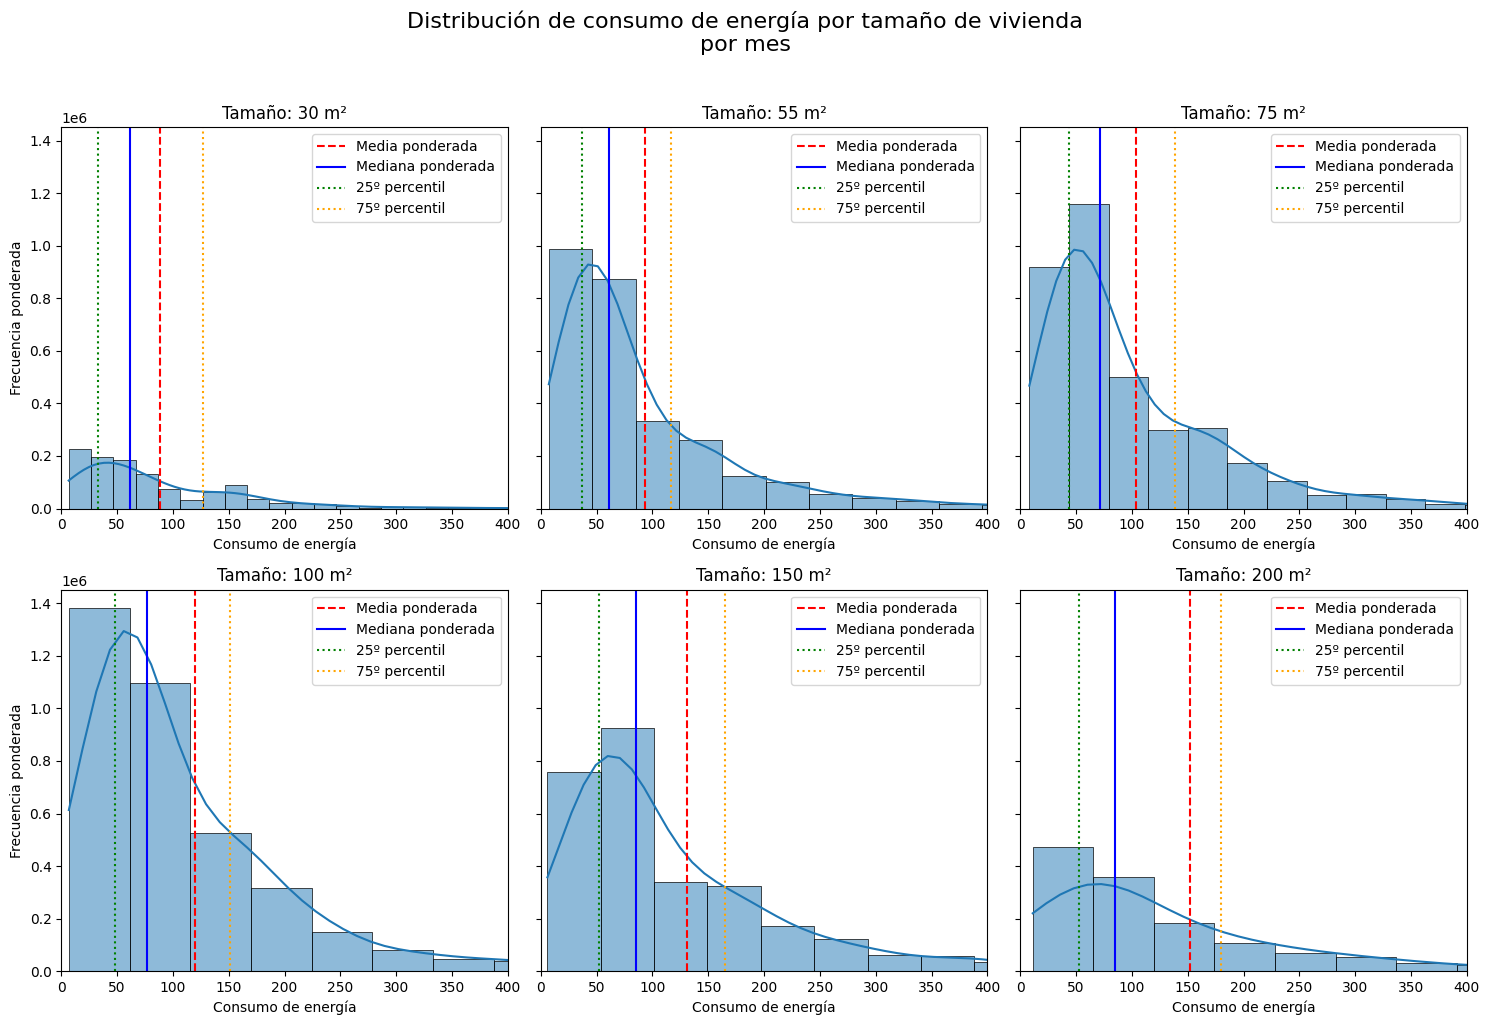

In [25]:
viv = ENCEVI_CONSUMO

# Función para calcular la mediana ponderada
def weighted_median(values, weights):
    order = np.argsort(values)
    sorted_vals = values[order]
    sorted_w = weights[order]
    cum_weights = np.cumsum(sorted_w)
    cutoff = cum_weights[-1] / 2.0
    return sorted_vals[cum_weights >= cutoff][0]

# Función para calcular percentiles ponderados (por ejemplo, 25º o 75º)
def weighted_percentile(values, weights, percentile):
    order = np.argsort(values)
    sorted_vals = values[order]
    sorted_w = weights[order]
    cum_weights = np.cumsum(sorted_w)
    cutoff = percentile/100.0 * cum_weights[-1]
    return sorted_vals[cum_weights >= cutoff][0]

# Lista de tamaños (m²) válidos
tamanos = [30, 55, 75, 100, 150, 200]

# Filtrar el dataframe para viviendas con m2 definidos en esos tamaños
viv_filtrado = viv[viv['m2'].isin(tamanos)]

# Crear la figura con 6 subplots (2 filas x 3 columnas), compartiendo la escala del eje Y
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)

# Iterar por cada tamaño
for ax, tam in zip(axes.flatten(), tamanos):
    df_temp = viv_filtrado[viv_filtrado['m2'] == tam]
    
    # Graficar el histograma ponderado (se usa weights=df_temp['factor_sem'])
    sns.histplot(
        data=df_temp, 
        x='kwh_mes', 
        bins=45, 
        kde=True, 
        weights=df_temp['factor_sem'], 
        ax=ax)
    ax.set_xlim(0,400)
    # Extraer los valores de consumo y los pesos
    consumo = df_temp['kwh_mes'].values
    pesos = df_temp['factor_sem'].values
    
    # Calcular la media ponderada
    media_ponderada = np.average(consumo, weights=pesos)
    
    # Calcular la mediana ponderada y los percentiles 25 y 75
    mediana_ponderada = weighted_median(consumo, pesos)
    p25 = weighted_percentile(consumo, pesos, 25)
    p75 = weighted_percentile(consumo, pesos, 75)
    
    # Marcar los valores calculados en el gráfico con líneas verticales
    ax.axvline(media_ponderada, color='red', linestyle='--', label='Media ponderada')
    ax.axvline(mediana_ponderada, color='blue', linestyle='-', label='Mediana ponderada')
    ax.axvline(p25, color='green', linestyle=':', label='25º percentil')
    ax.axvline(p75, color='orange', linestyle=':', label='75º percentil')
    
    ax.set_title(f"Tamaño: {tam} m²")
    ax.set_xlabel("Consumo de energía kWh/mes")
    ax.set_ylabel("Frecuencia ponderada")
    ax.legend()

plt.suptitle("Distribución de consumo de energía por tamaño de vivienda", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [26]:

# Función para calcular la mediana ponderada
def weighted_median(values, weights):
    # Ordena los valores y pesos según los valores
    order = np.argsort(values)
    sorted_vals = values[order]
    sorted_w = weights[order]
    
    # Suma acumulada de los pesos
    cum_weights = np.cumsum(sorted_w)
    cutoff = cum_weights[-1] / 2.0
    return sorted_vals[cum_weights >= cutoff][0]

# Función para calcular percentiles ponderados
def weighted_percentile(values, weights, percentile):
    order = np.argsort(values)
    sorted_vals = values[order]
    sorted_w = weights[order]
    cum_weights = np.cumsum(sorted_w)
    cutoff = percentile / 100.0 * cum_weights[-1]
    return sorted_vals[cum_weights >= cutoff][0]

# Filtrar el DataFrame para considerar solo los tamaños de interés
tamanos_validos = [30, 55, 75, 100, 150, 200]
viv_filtrado = viv[viv['m2'].isin(tamanos_validos)]
total_total = viv.factor_sem.sum()

# Lista para almacenar los resultados por cada grupo de tamaño
resultados = []

# Agrupar por el tamaño de vivienda (la columna 'm2')
for tam, grupo in viv_filtrado.groupby('m2'):
    # Extraer los valores de consumo y los pesos
    consumo = grupo['kwh_mes'].values
    pesos = grupo['factor_sem'].values
    
    # Calcular la media ponderada
    media_ponderada = np.average(consumo, weights=pesos)
    # Calcular la mediana ponderada
    mediana_ponderada = weighted_median(consumo, pesos)
    # Calcular percentiles ponderados (opcional)
    p25 = weighted_percentile(consumo, pesos, 25)
    p75 = weighted_percentile(consumo, pesos, 75)
    # Total de viviendas ponderadas representadas en este grupo
    total_viviendas = pesos.sum()
    total_energia = total_viviendas*media_ponderada
    # Número de observaciones en el grupo (sin ponderar)
    n_observaciones = len(grupo)
    
    resultados.append({
        'm2': tam,
        'Media kWh': media_ponderada,
        'Mediana kWh': mediana_ponderada,
        'Percentil 25 kWh': p25,
        'Percentil 75 kWh': p75,
        '% viviendas': (total_viviendas/total_total*100).round(2),
        # "Total energia MWh muestra": total_energia/1e6,
        'N (observaciones)': n_observaciones
    })

# Convertir a DataFrame para crear la tabla resumen
tabla_resumen = pd.DataFrame(resultados).sort_values('m2').round(2)
tabla_resumen

,m2,Media kWh,Mediana kWh,Percentil 25 kWh,Percentil 75 kWh,% viviendas,N (observaciones)
0,30.0,88.40,61.31,32.80,127.17,7.28,1058
1,55.0,93.26,61.52,36.82,117.01,18.31,2564
2,75.0,103.88,71.15,43.59,138.74,23.54,3256
3,100.0,119.66,76.99,48.40,151.50,23.75,3612
4,150.0,130.99,85.62,52.11,165.04,18.38,2678
5,200.0,151.79,85.04,52.78,179.94,8.74,1285


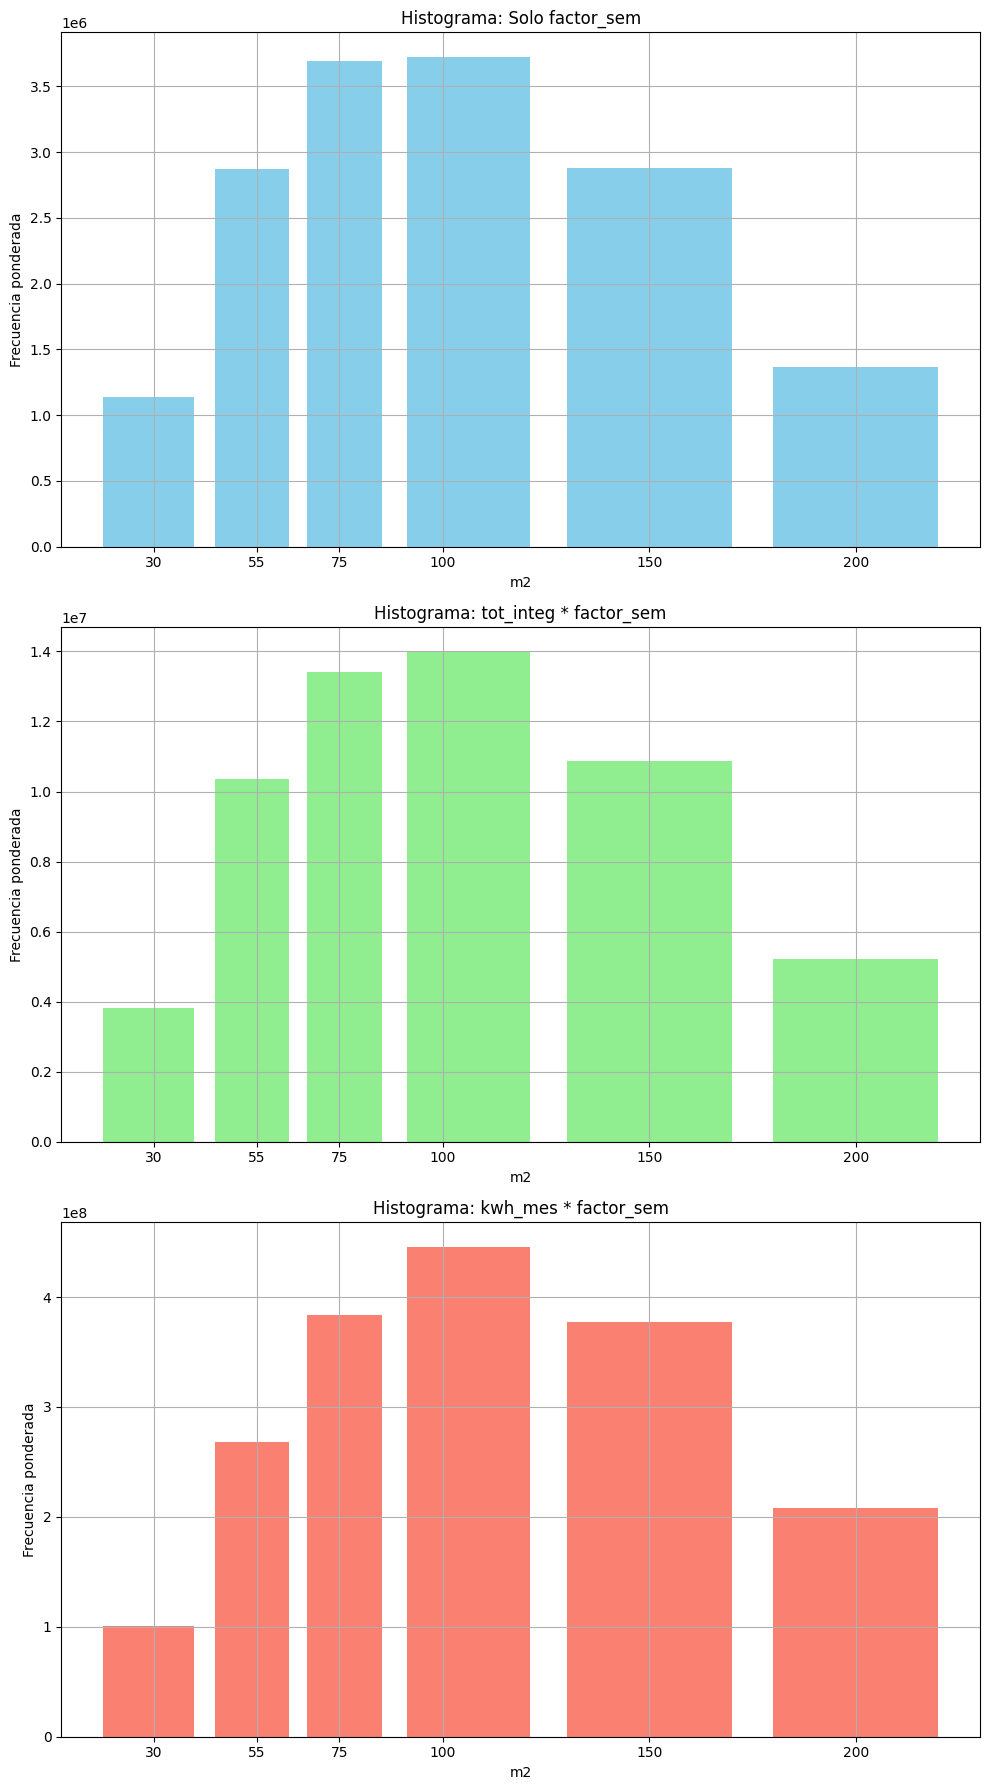

In [27]:
import matplotlib.pyplot as plt

# Crear un DataFrame temporal
df_temp = ENCEVI_CONSUMO.copy()

# Definir los pesos
pesos_1 = df_temp['factor_sem']
pesos_2 = df_temp['tot_integ'] * df_temp['factor_sem']
pesos_3 = df_temp['kwh_mes'] * df_temp['factor_sem']

# Variable eje x: 'm2'
variable_x = df_temp['m2']

# Definir los bins para los tamaños específicos
tamanos = [30, 55, 75, 100, 150, 200]
# Para que matplotlib trate bien los bins, extendemos los bordes un poco
bins = [15, 42.5, 65, 87.5, 125, 175, 225]  

# Configurar subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 18))

# Histograma 1: Solo factor_sem
axs[0].hist(variable_x, bins=bins, weights=pesos_1, color='skyblue', rwidth=0.8)
axs[0].set_title('Histograma: Solo factor_sem')
axs[0].set_xlabel('m2')
axs[0].set_ylabel('Frecuencia ponderada')
axs[0].set_xticks(tamanos)  # Poner las etiquetas exactas
axs[0].grid(True)

# Histograma 2: tot_integ * factor_sem
axs[1].hist(variable_x, bins=bins, weights=pesos_2, color='lightgreen', rwidth=0.8)
axs[1].set_title('Histograma: tot_integ * factor_sem')
axs[1].set_xlabel('m2')
axs[1].set_ylabel('Frecuencia ponderada')
axs[1].set_xticks(tamanos)
axs[1].grid(True)

# Histograma 3: kwh_mes * factor_sem
axs[2].hist(variable_x, bins=bins, weights=pesos_3, color='salmon', rwidth=0.8)
axs[2].set_title('Histograma: kwh_mes * factor_sem')
axs[2].set_xlabel('m2')
axs[2].set_ylabel('Frecuencia ponderada')
axs[2].set_xticks(tamanos)
axs[2].grid(True)

# Ajustar el espaciado
plt.tight_layout()
plt.show()


In [28]:
# Crear una nueva columna con el producto
ENCEVI_CONSUMO['peso_integrantes'] = ENCEVI_CONSUMO['factor_sem'] * ENCEVI_CONSUMO['tot_integ']

# Agrupar por 'm2' y sumar el producto
tabla_resultado = ENCEVI_CONSUMO.groupby('m2')['peso_integrantes'].sum().reset_index()

# Mostrar la tabla
print(tabla_resultado)


      m2  peso_integrantes
0   30.0           3809658
1   55.0          10356899
2   75.0          13412616
3  100.0          13988210
4  150.0          10863846
5  200.0           5229377


C:\Users\roele\AppData\Local\Temp\ipykernel_45200\1624997211.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ENCEVI_CONSUMO['peso_integrantes'] = ENCEVI_CONSUMO['factor_sem'] * ENCEVI_CONSUMO['tot_integ']


In [29]:
# Agrupar por 'm2' y sumar el producto
tabla_resultado = ENCEVI_CONSUMO.groupby('m2')['factor_sem'].sum().reset_index()

# Mostrar la tabla
print(tabla_resultado)

      m2  factor_sem
0   30.0     1140864
1   55.0     2870627
2   75.0     3691509
3  100.0     3724577
4  150.0     2882760
5  200.0     1369666


In [30]:
# Crear una nueva columna con el producto
ENCEVI_CONSUMO['peso_consumo'] = ENCEVI_CONSUMO['factor_sem'] * ENCEVI_CONSUMO['kwh_mes']

# Agrupar por 'm2' y sumar el producto
tabla_resultado = ENCEVI_CONSUMO.groupby('m2')['peso_consumo'].sum().reset_index()

# Mostrar la tabla
print(tabla_resultado)

      m2  peso_consumo
0   30.0  1.008536e+08
1   55.0  2.677101e+08
2   75.0  3.834638e+08
3  100.0  4.456896e+08
4  150.0  3.776080e+08
5  200.0  2.079007e+08


C:\Users\roele\AppData\Local\Temp\ipykernel_45200\1211904664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ENCEVI_CONSUMO['peso_consumo'] = ENCEVI_CONSUMO['factor_sem'] * ENCEVI_CONSUMO['kwh_mes']


Podríamos ver en qué estados se encuentran más las casas de 75 y 100m2 y de ahí ver los climas a partir de los municipios

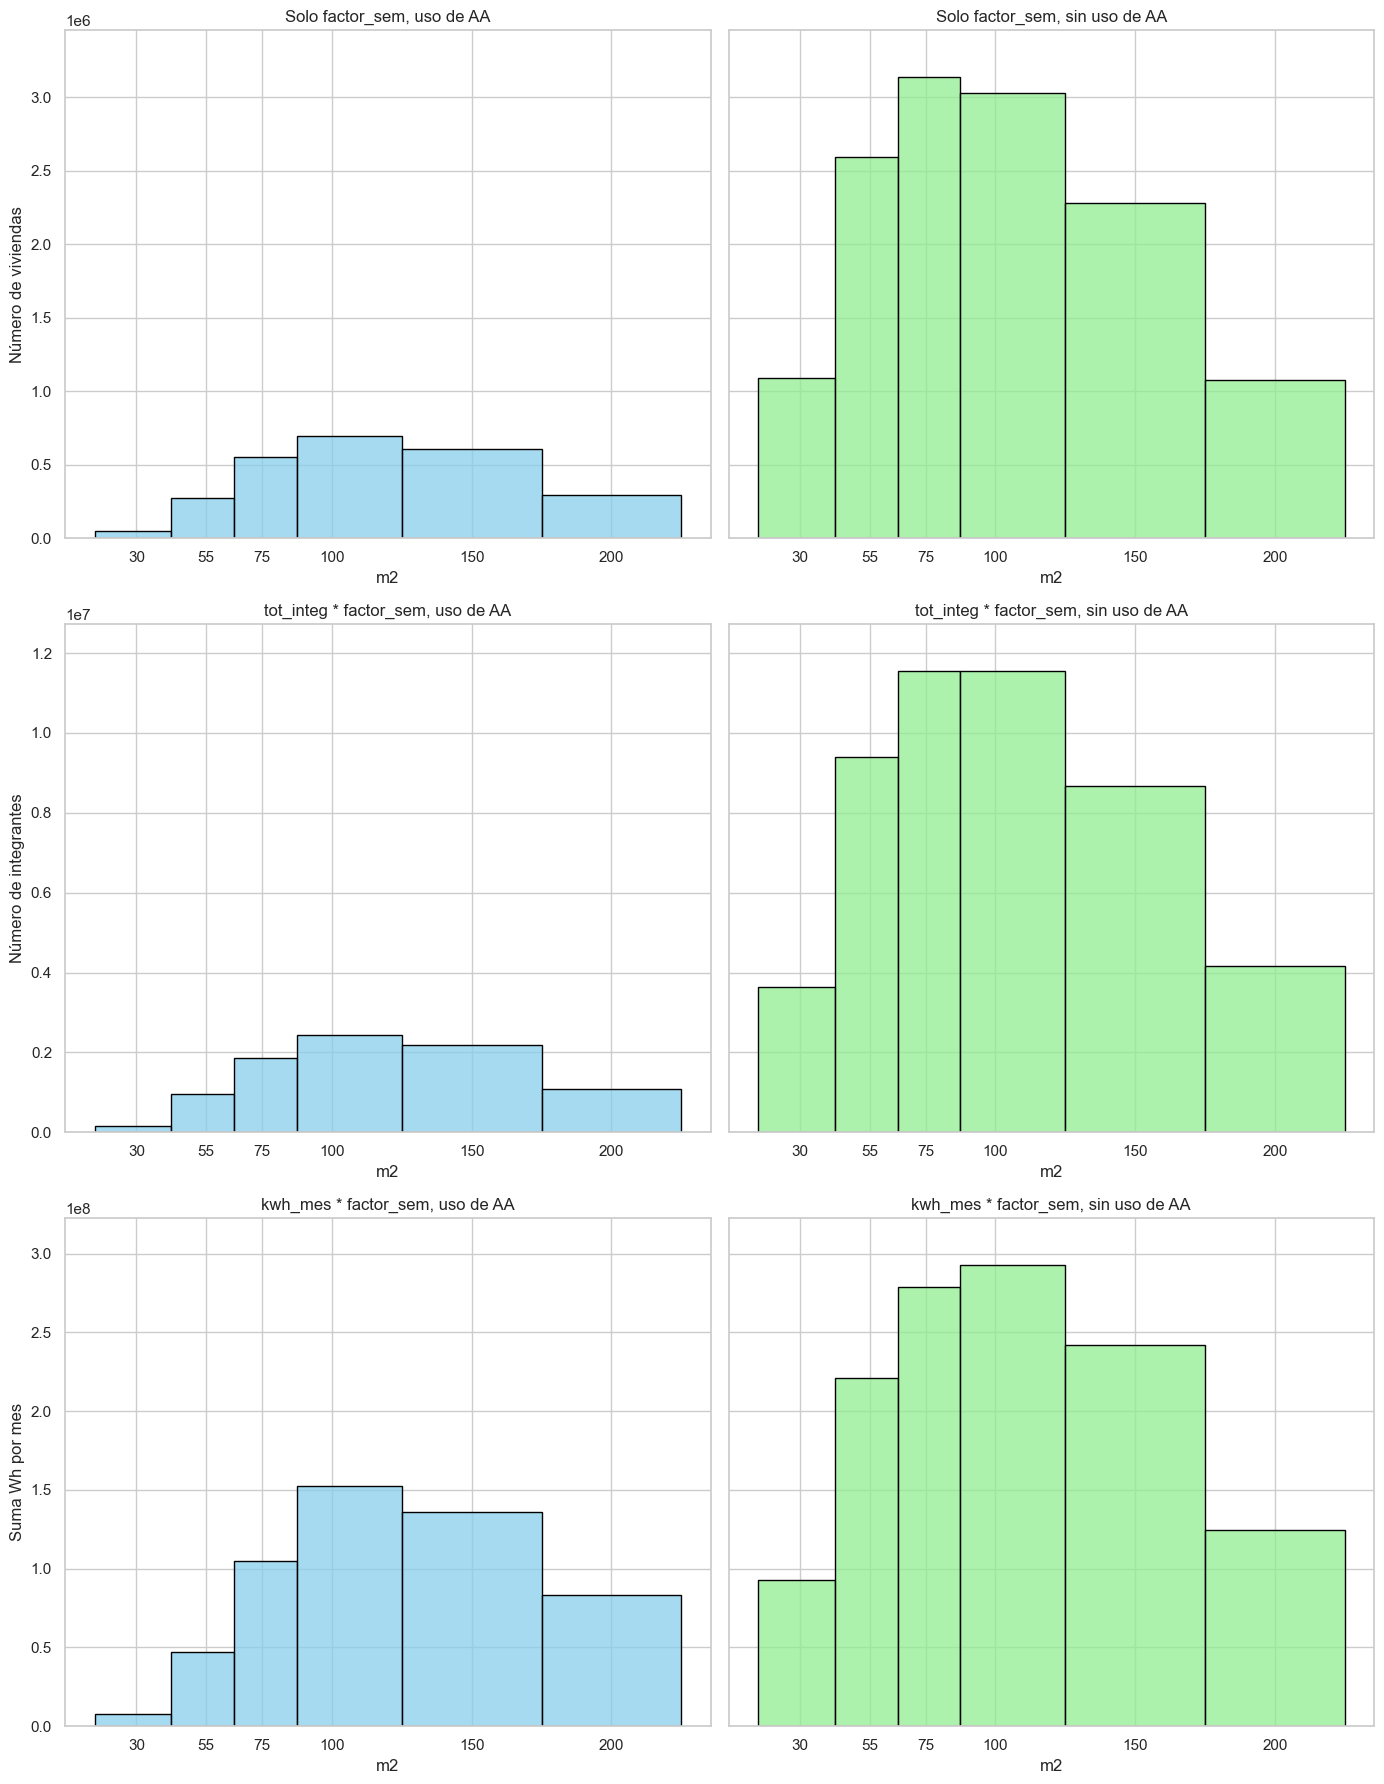

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configuración de estilo Seaborn
sns.set(style="whitegrid")

# Definir bins y tamaños
tamanos = [30, 55, 75, 100, 150, 200]
bins = [15, 42.5, 65, 87.5, 125, 175, 225]

# Filtrar los datos
df_aa = ENCEVI_CONSUMO[ENCEVI_CONSUMO["uso_aire"] == 1].copy()
df_noaa = ENCEVI_CONSUMO[ENCEVI_CONSUMO["uso_aire"] == 2].copy()

# Pesos
pesos_aa = [
    df_aa['factor_sem'],
    df_aa['tot_integ'] * df_aa['factor_sem'],
    df_aa['kwh_mes'] * df_aa['factor_sem']
]

pesos_noaa = [
    df_noaa['factor_sem'],
    df_noaa['tot_integ'] * df_noaa['factor_sem'],
    df_noaa['kwh_mes'] * df_noaa['factor_sem']
]

# Variable x
x_aa = df_aa['m2']
x_noaa = df_noaa['m2']

# Títulos para los histogramas
titulos = ['Solo factor_sem', 'tot_integ * factor_sem', 'kwh_mes * factor_sem']

# Etiquetas específicas para el eje y
etiquetas_y = ['Número de viviendas', 'Número de integrantes', 'Suma Wh por mes']

# Crear subplots 3 filas, 2 columnas
fig, axs = plt.subplots(3, 2, figsize=(14, 18), sharex=False, sharey='row')

for i in range(3):
    # Hist AA
    counts_aa, _ = np.histogram(x_aa, bins=bins, weights=pesos_aa[i])
    counts_noaa, _ = np.histogram(x_noaa, bins=bins, weights=pesos_noaa[i])
    ymax = max(counts_aa.max(), counts_noaa.max()) * 1.1

    # Con AA
    sns.histplot(
        x=x_aa,
        weights=pesos_aa[i],
        bins=bins,
        ax=axs[i, 0],
        color='skyblue',
        edgecolor='black'
    )
    axs[i, 0].set_title(f'{titulos[i]}, uso de AA')
    axs[i, 0].set_ylabel(etiquetas_y[i])
    axs[i, 0].set_xticks(tamanos)
    axs[i, 0].set_ylim(0, ymax)
    axs[i, 0].set_xlabel('m2')

    # Sin AA
    sns.histplot(
        x=x_noaa,
        weights=pesos_noaa[i],
        bins=bins,
        ax=axs[i, 1],
        color='lightgreen',
        edgecolor='black'
    )
    axs[i, 1].set_title(f'{titulos[i]}, sin uso de AA')
    axs[i, 1].set_xticks(tamanos)
    axs[i, 1].set_ylim(0, ymax)
    axs[i, 1].set_xlabel('m2')

# Ajuste final
plt.tight_layout()
plt.show()


Propuesta para seleccionar la o las tipologias (m2) de las casas
por ejemplo, 
Escojo la de 100 m2 porque es la que tiene los datos mayores cuando no se separa entre uso y no uso de AA

Criterios de selección: 
- Ser la que se contruye más veces
- Ser la que mas personas representa
- Ser la que más energía acumulada consume
- La que más datos tenga Hernandez (el consumo tendrá mayor resolución)
    - La que más subcidio recibe
    - La que tenga menos bioclimas
- La que tenga más viviendas en estrato económico bajo
- Las que tengan datos más completos en uso de aparatos
- 

In [32]:
ENCEVI_CONSUMO.columns

Index(['factor', 'bill_days', 'munic_name', 'bill_kwh_estimation', 'total_niv',
       'super_ter', 'super_cons', 'tot_cuart', 'electri', 'local_com',
       'elect_loc', 'uso_aire', 'est_socio', 'factor_sem', 'entidad',
       'tot_integ', 'm2', 'kwh_mes', 'kwh_m2_mes', 'peso_integrantes',
       'peso_consumo'],
      dtype='object')

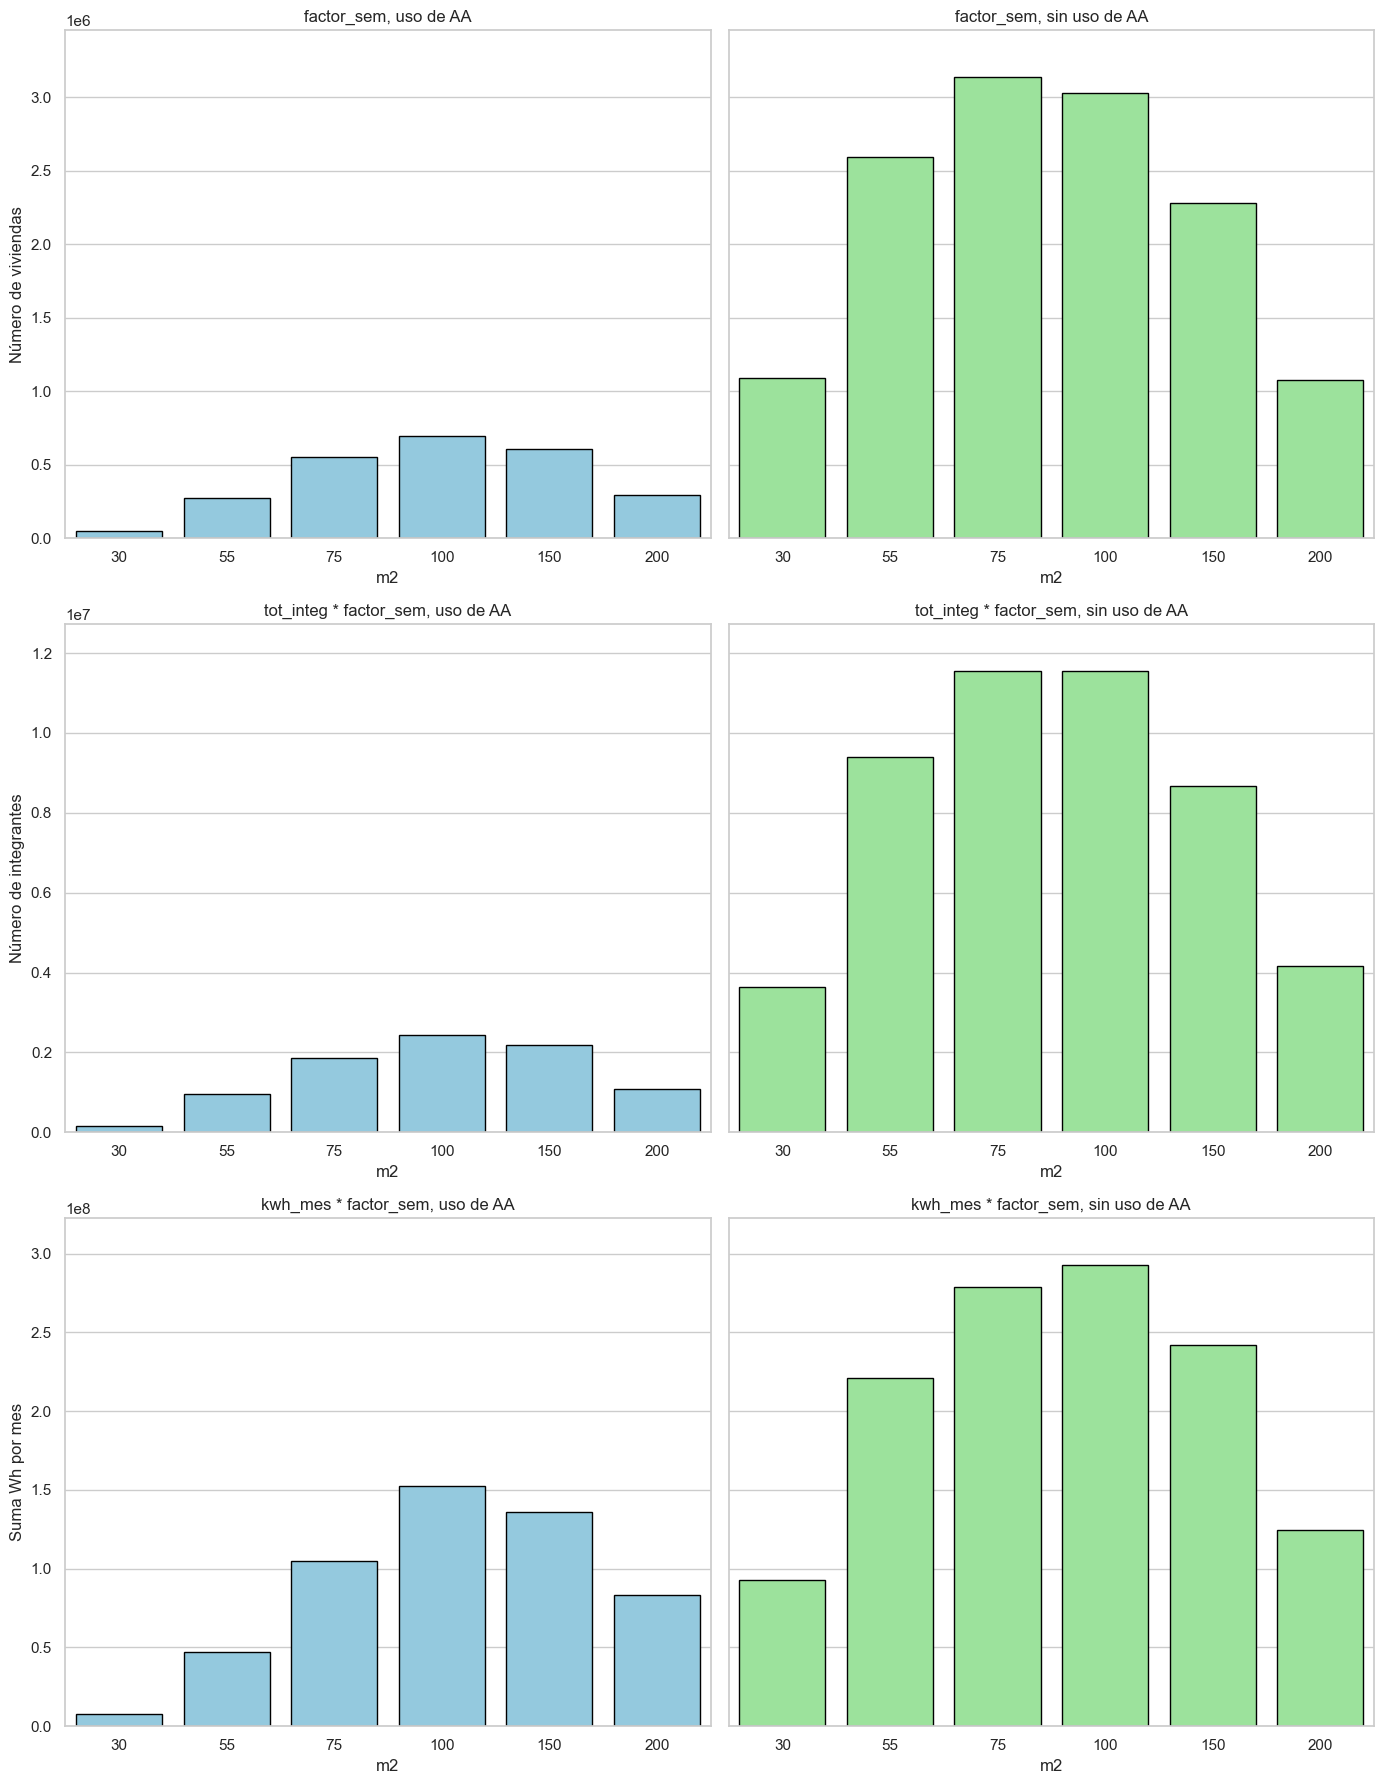

   Grupo                 Métrica   m2    Frecuencia  Porcentaje
0     AA              factor_sem   30  5.205300e+04    2.106432
1   NoAA              factor_sem   30  1.088811e+06    8.243037
2     AA              factor_sem   55  2.764060e+05   11.185337
3   NoAA              factor_sem   55  2.594221e+06   19.640011
4     AA              factor_sem   75  5.524760e+05   22.357076
5   NoAA              factor_sem   75  3.139033e+06   23.764607
6     AA              factor_sem  100  6.941890e+05   28.091784
7   NoAA              factor_sem  100  3.030388e+06   22.942091
8     AA              factor_sem  150  6.040520e+05   24.444205
9   NoAA              factor_sem  150  2.278708e+06   17.251364
10    AA              factor_sem  200  2.919700e+05   11.815166
11  NoAA              factor_sem  200  1.077696e+06    8.158889
12    AA  tot_integ * factor_sem   30  1.658950e+05    1.911697
13  NoAA  tot_integ * factor_sem   30  3.643763e+06    7.438875
14    AA  tot_integ * factor_sem   55  9

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Configurar estilo
sns.set(style="whitegrid")

# Valores posibles de m2
tamanos = [30, 55, 75, 100, 150, 200]

# Filtrar los datos
df_aa = ENCEVI_CONSUMO[ENCEVI_CONSUMO["uso_aire"] == 1].copy()
df_noaa = ENCEVI_CONSUMO[ENCEVI_CONSUMO["uso_aire"] == 2].copy()

# Métricas
metrica_nombres = ['factor_sem', 'tot_integ * factor_sem', 'kwh_mes * factor_sem']
etiquetas_y = ['Número de viviendas', 'Número de integrantes', 'Suma Wh por mes']

# Subplots
fig, axs = plt.subplots(3, 2, figsize=(14, 18), sharex=False, sharey='row')
tabla_resultados = []

for i in range(3):
    if i == 0:
        df_aa['peso'] = df_aa['factor_sem']
        df_noaa['peso'] = df_noaa['factor_sem']
    elif i == 1:
        df_aa['peso'] = df_aa['tot_integ'] * df_aa['factor_sem']
        df_noaa['peso'] = df_noaa['tot_integ'] * df_noaa['factor_sem']
    else:
        df_aa['peso'] = df_aa['kwh_mes'] * df_aa['factor_sem']
        df_noaa['peso'] = df_noaa['kwh_mes'] * df_noaa['factor_sem']

    # Agrupar por m2
    grupo_aa = df_aa.groupby('m2')['peso'].sum().reindex(tamanos, fill_value=0)
    grupo_noaa = df_noaa.groupby('m2')['peso'].sum().reindex(tamanos, fill_value=0)

    # Totales para porcentajes
    total_aa = grupo_aa.sum()
    total_noaa = grupo_noaa.sum()

    # Resultados a tabla
    for m2_val in tamanos:
        tabla_resultados.append({
            'Grupo': 'AA',
            'Métrica': metrica_nombres[i],
            'm2': m2_val,
            'Frecuencia': grupo_aa[m2_val],
            'Porcentaje': (grupo_aa[m2_val] / total_aa) * 100 if total_aa > 0 else 0
        })
        tabla_resultados.append({
            'Grupo': 'NoAA',
            'Métrica': metrica_nombres[i],
            'm2': m2_val,
            'Frecuencia': grupo_noaa[m2_val],
            'Porcentaje': (grupo_noaa[m2_val] / total_noaa) * 100 if total_noaa > 0 else 0
        })

    # Graficar
    ymax = max(grupo_aa.max(), grupo_noaa.max()) * 1.1

    sns.barplot(x=grupo_aa.index, y=grupo_aa.values, ax=axs[i, 0], color='skyblue', edgecolor='black')
    axs[i, 0].set_title(f'{metrica_nombres[i]}, uso de AA')
    axs[i, 0].set_ylabel(etiquetas_y[i])
    axs[i, 0].set_xlabel('m2')
    axs[i, 0].set_ylim(0, ymax)

    sns.barplot(x=grupo_noaa.index, y=grupo_noaa.values, ax=axs[i, 1], color='lightgreen', edgecolor='black')
    axs[i, 1].set_title(f'{metrica_nombres[i]}, sin uso de AA')
    axs[i, 1].set_xlabel('m2')
    axs[i, 1].set_ylim(0, ymax)

plt.tight_layout()
plt.show()

# DataFrame final
df_resultados = pd.DataFrame(tabla_resultados)
print(df_resultados)


In [34]:
resultados_conAA = df_resultados[df_resultados.Grupo == "AA"]
resultados_conAA

,Grupo,Métrica,m2,Frecuencia,Porcentaje
0,AA,factor_sem,30,5.205300e+04,2.106432
2,AA,factor_sem,55,2.764060e+05,11.185337
4,AA,factor_sem,75,5.524760e+05,22.357076
6,AA,factor_sem,100,6.941890e+05,28.091784
8,AA,factor_sem,150,6.040520e+05,24.444205
10,AA,factor_sem,200,2.919700e+05,11.815166
12,AA,tot_integ * factor_sem,30,1.658950e+05,1.911697
14,AA,tot_integ * factor_sem,55,9.671300e+05,11.144760
16,AA,tot_integ * factor_sem,75,1.863685e+06,21.476246
18,AA,tot_integ * factor_sem,100,2.426757e+06,27.964828


Propuesta para seleccionar la o las tipologias (m2) de las casas
por ejemplo, 
Escojo la de 100 m2 porque es la que tiene los datos mayores cuando no se separa entre uso y no uso de AA

Criterios de selección: 
- Ser la que se contruye más veces
- Ser la que mas personas representa
- Ser la que más energía acumulada consume
- Haber conservado más datos despues de la limpieza y la unión
- Tener más viviendas en la encuesta original de la ENCEVI y que eso no haya cambiado al unirlo con Hernandez
    - La que más subcidio recibe
    - La que tenga menos bioclimas
    - La que tenga más viviendas en estrato económico bajo
    - Las que tengan datos más completos en uso de aparatos
- 

In [35]:
top2_frecuencias = (
    df_resultados
    .groupby(['Grupo', 'Métrica'], group_keys=True)
    .apply(lambda g: g.nlargest(2, 'Frecuencia'), include_groups=False)
    .reset_index(drop=False)
)
top2_frecuencias

,Grupo,Métrica,level_2,m2,Frecuencia,Porcentaje
0,AA,factor_sem,6,100,6.941890e+05,28.091784
1,AA,factor_sem,8,150,6.040520e+05,24.444205
2,AA,kwh_mes * factor_sem,30,100,1.527071e+08,28.736183
3,AA,kwh_mes * factor_sem,32,150,1.359129e+08,25.575886
4,AA,tot_integ * factor_sem,18,100,2.426757e+06,27.964828
5,AA,tot_integ * factor_sem,20,150,2.183761e+06,25.164654
6,NoAA,factor_sem,5,75,3.139033e+06,23.764607
7,NoAA,factor_sem,7,100,3.030388e+06,22.942091
8,NoAA,kwh_mes * factor_sem,31,100,2.929825e+08,23.404609
9,NoAA,kwh_mes * factor_sem,29,75,2.785450e+08,22.251286


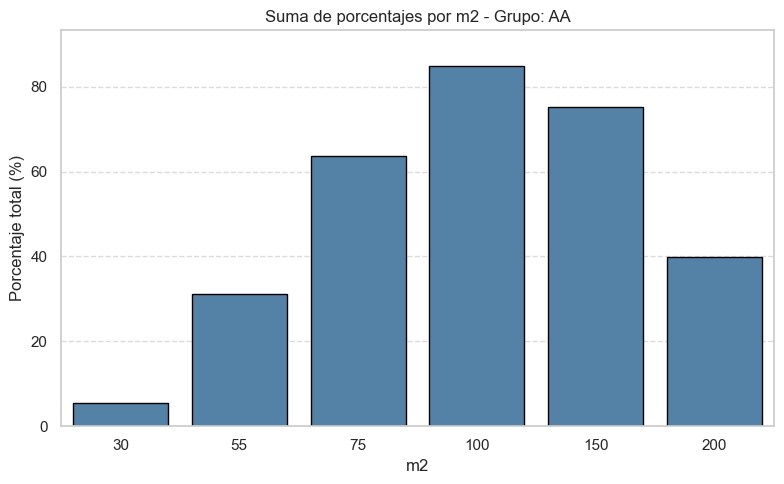

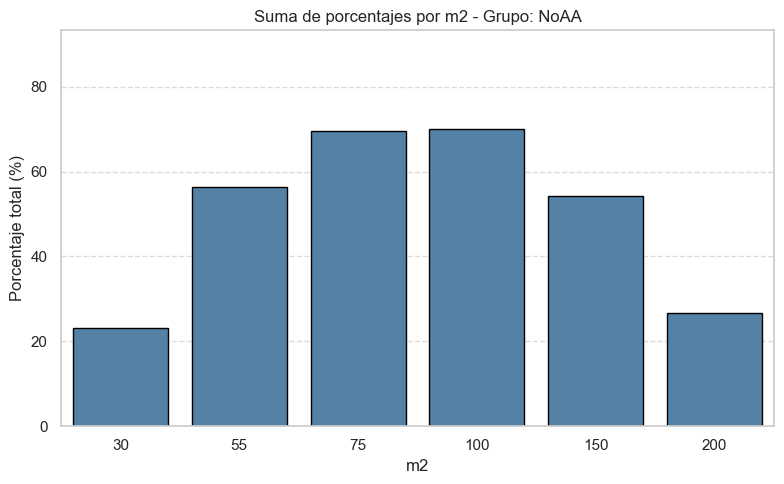

In [36]:


import seaborn as sns
import matplotlib.pyplot as plt

# Agrupar por grupo y m2, sumando porcentajes de todas las métricas
df_agrupado = (
    df_resultados
    .groupby(['Grupo', 'm2'], as_index=False)['Porcentaje']
    .sum()
)

# Lista de grupos
grupos = df_agrupado['Grupo'].unique()

# Graficar una figura por grupo
for grupo in grupos:
    df_plot = df_agrupado[df_agrupado['Grupo'] == grupo]

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_plot, x='m2', y='Porcentaje', color='steelblue', edgecolor='black')
    plt.title(f'Suma de porcentajes por m2 - Grupo: {grupo}')
    plt.xlabel('m2')
    plt.ylabel('Porcentaje total (%)')
    plt.ylim(0, df_agrupado['Porcentaje'].max() * 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [37]:
ENCEVI

,folio,total_niv,super_ter,super_cons,tot_cuart,electri,local_com,elect_loc,uso_aire,est_socio,factor_sem,entidad,tot_integ
0,1,2,3,7,11,1,2,<NA>,2,3,373,1,1
1,2,1,3,3,6,1,2,<NA>,2,3,373,1,4
2,3,2,3,7,5,1,2,<NA>,2,3,373,1,4
3,4,1,3,4,6,1,2,<NA>,2,3,373,1,1
4,5,1,3,4,5,1,2,<NA>,2,3,373,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28948,28949,1,9,9,3,1,2,<NA>,2,2,382,32,4
28949,28950,1,9,9,2,1,2,<NA>,2,2,382,32,3
28950,28951,1,9,9,5,1,2,<NA>,2,2,382,32,2
28951,28952,1,6,4,4,1,2,<NA>,2,2,382,32,4


In [38]:
mapeo_m2 = {
    1: 30,
    2: 55,
    3: 75,
    4: 100,
    5: 150,
    6: 200,
    7: np.nan,
    9: np.nan
}

# Crear la nueva columna "m2" aplicando el diccionario de mapeo
ENCEVI['m2'] = ENCEVI['super_cons'].map(mapeo_m2)
ENCEVI.isna().sum()

folio             0
total_niv         0
super_ter         0
super_cons        0
tot_cuart         0
electri           0
local_com       276
elect_loc     27106
uso_aire        184
est_socio         0
factor_sem        0
entidad           0
tot_integ         0
m2             7738
dtype: int64

In [39]:
ENCEVI = ENCEVI.dropna(subset=['m2'])
ENCEVI.isna().sum()

folio             0
total_niv         0
super_ter         0
super_cons        0
tot_cuart         0
electri           0
local_com       219
elect_loc     19920
uso_aire        151
est_socio         0
factor_sem        0
entidad           0
tot_integ         0
m2                0
dtype: int64

In [40]:
# Para ENCEVI
ENCEVI_AA = ENCEVI[ENCEVI.uso_aire == 1].copy()

suma_encevi_AA = ENCEVI_AA.groupby('m2')['factor_sem'].sum().reset_index(name='Num_viviendas')
suma_encevi_AA.set_index('m2', inplace=True)
suma_encevi_AA

,Num_viviendas
m2,
30.0,90563
55.0,433151
75.0,786807
100.0,980824
150.0,851831
200.0,433461


In [41]:
# Para ENCEVI
ENCEVI_sin_AA = ENCEVI[ENCEVI.uso_aire == 2].copy()

suma_encevi_sin_AA = ENCEVI_sin_AA.groupby('m2')['factor_sem'].sum().reset_index(name='Num_viviendas')
suma_encevi_sin_AA.set_index('m2', inplace=True)
suma_encevi_sin_AA

,Num_viviendas
m2,
30.0,2364146
55.0,4221428
75.0,4477328
100.0,4335216
150.0,3289792
200.0,1683127


In [42]:
# Para ENCEVI_CONSUMO
ENCEVI_CONSUMO_AA = ENCEVI_CONSUMO[ENCEVI_CONSUMO.uso_aire == 1].copy()

suma_encevi_consumo_AA = ENCEVI_CONSUMO_AA.groupby('m2')['factor_sem'].sum().reset_index(name='Num_viviendas')
suma_encevi_consumo_AA.set_index('m2', inplace=True)
suma_encevi_consumo_AA

,Num_viviendas
m2,
30.0,52053
55.0,276406
75.0,552476
100.0,694189
150.0,604052
200.0,291970


In [43]:
# Para ENCEVI_CONSUMO
ENCEVI_CONSUMO_sin_AA = ENCEVI_CONSUMO[ENCEVI_CONSUMO.uso_aire == 2].copy()

suma_encevi_consumo_sin_AA = ENCEVI_CONSUMO_sin_AA.groupby('m2')['factor_sem'].sum().reset_index(name='Num_viviendas')
suma_encevi_consumo_sin_AA.set_index('m2', inplace=True)
suma_encevi_consumo_sin_AA

,Num_viviendas
m2,
30.0,1088811
55.0,2594221
75.0,3139033
100.0,3030388
150.0,2278708
200.0,1077696


In [44]:
datos_tirados_AA = pd.DataFrame()
datos_tirados_sin_AA = pd.DataFrame()
# datos_tirados['%_de_datos_tirados'] = ((suma_encevi.Num_viviendas - suma_encevi_consumo.Num_viviendas)/suma_encevi.Num_viviendas*100)

# datos_tirados

In [45]:
datos_tirados_AA['%_de_datos_finales'] = 100-((suma_encevi_AA.Num_viviendas - suma_encevi_consumo_AA.Num_viviendas)/suma_encevi_AA.Num_viviendas*100)

datos_tirados_AA

,%_de_datos_finales
m2,
30.0,57.477115
55.0,63.812850
75.0,70.217474
100.0,70.776103
150.0,70.912188
200.0,67.357848


In [46]:
datos_tirados_sin_AA['%_de_datos_finales'] = 100-((suma_encevi_sin_AA.Num_viviendas - suma_encevi_consumo_sin_AA.Num_viviendas)/suma_encevi_sin_AA.Num_viviendas*100)

datos_tirados_sin_AA

,%_de_datos_finales
m2,
30.0,46.055151
55.0,61.453636
75.0,70.109516
100.0,69.901661
150.0,69.266020
200.0,64.029393


In [47]:
datos_tirados_AA['%_de_datos_ENCEVI'] = suma_encevi_AA.Num_viviendas/suma_encevi_AA.Num_viviendas.sum()*100

datos_tirados_AA

,%_de_datos_finales,%_de_datos_ENCEVI
m2,,
30.0,57.477115,2.532071
55.0,63.812850,12.110566
75.0,70.217474,21.998514
100.0,70.776103,27.423079
150.0,70.912188,23.816535
200.0,67.357848,12.119234


In [48]:
datos_tirados_sin_AA['%_de_datos_ENCEVI'] = suma_encevi_sin_AA.Num_viviendas/suma_encevi_sin_AA.Num_viviendas.sum()*100

datos_tirados_sin_AA

,%_de_datos_finales,%_de_datos_ENCEVI
m2,,
30.0,46.055151,11.605428
55.0,61.453636,20.722696
75.0,70.109516,21.978891
100.0,69.901661,21.281273
150.0,69.266020,16.149360
200.0,64.029393,8.262353


In [49]:
datos_tirados_AA['%_de_datos_Hernandez'] = suma_encevi_consumo_AA.Num_viviendas/suma_encevi_consumo_AA.Num_viviendas.sum()*100

datos_tirados_AA

,%_de_datos_finales,%_de_datos_ENCEVI,%_de_datos_Hernandez
m2,,,
30.0,57.477115,2.532071,2.106432
55.0,63.812850,12.110566,11.185337
75.0,70.217474,21.998514,22.357076
100.0,70.776103,27.423079,28.091784
150.0,70.912188,23.816535,24.444205
200.0,67.357848,12.119234,11.815166


In [50]:
datos_tirados_sin_AA['%_de_datos_Hernandez'] = suma_encevi_consumo_sin_AA.Num_viviendas/suma_encevi_consumo_sin_AA.Num_viviendas.sum()*100

datos_tirados_sin_AA

,%_de_datos_finales,%_de_datos_ENCEVI,%_de_datos_Hernandez
m2,,,
30.0,46.055151,11.605428,8.243037
55.0,61.453636,20.722696,19.640011
75.0,70.109516,21.978891,23.764607
100.0,69.901661,21.281273,22.942091
150.0,69.266020,16.149360,17.251364
200.0,64.029393,8.262353,8.158889


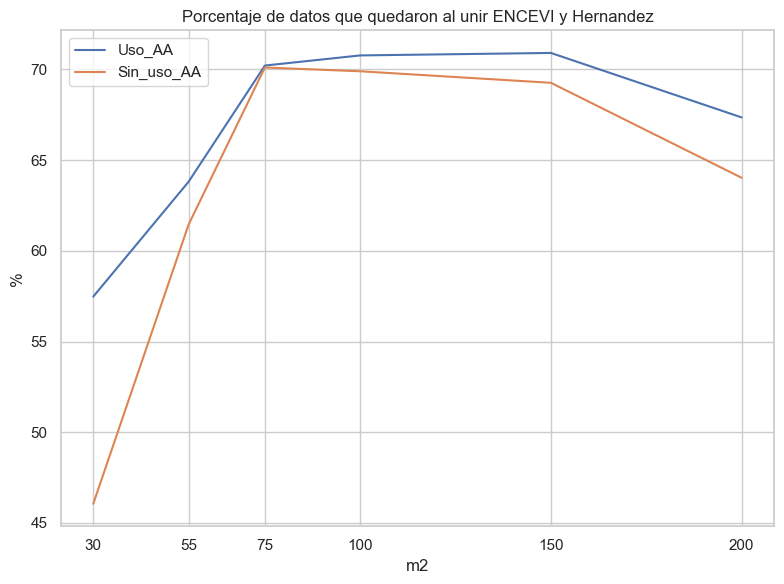

In [51]:
# Personaliza el título aquí:
titulo = "Porcentaje de datos que quedaron al unir ENCEVI y Hernandez"

plt.figure(figsize=(8, 6))

# Graficar cada serie
df_aa = datos_tirados_AA
df_noaa = datos_tirados_sin_AA

plt.plot(df_aa.index, df_aa['%_de_datos_finales'], label='Uso_AA')
plt.plot(df_noaa.index, df_noaa['%_de_datos_finales'], label='Sin_uso_AA')

# Limitar ticks del eje x a los valores únicos de ambos índices combinados
xticks = sorted(set(df_aa.index).union(set(df_noaa.index)))
plt.xticks(xticks)

# Etiquetas y estilo
plt.xlabel("m2")
plt.ylabel("%")
plt.title(titulo)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


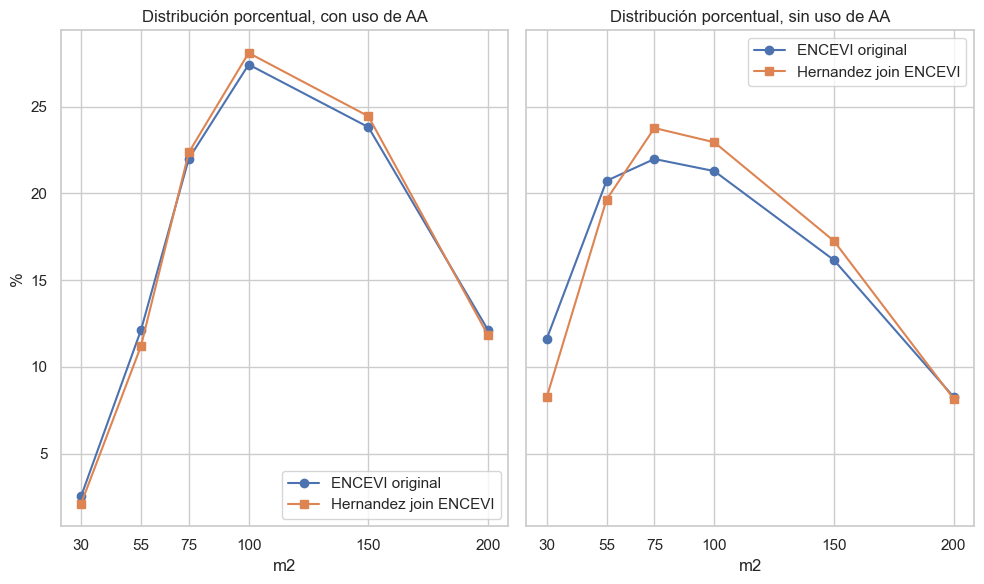

In [52]:
import matplotlib.pyplot as plt

# DataFrames
df1 = datos_tirados_AA
df2 = datos_tirados_sin_AA

# Títulos personalizados
titulo1 = "Distribución porcentual, con uso de AA"
titulo2 = "Distribución porcentual, sin uso de AA"

# Crear figura y ejes
fig, axs = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# Gráfica 1
axs[0].plot(df1.index, df1['%_de_datos_ENCEVI'], label='ENCEVI original', marker='o')
axs[0].plot(df1.index, df1['%_de_datos_Hernandez'], label='Hernandez join ENCEVI', marker='s')
axs[0].set_xticks(df1.index)  # Limitar el eje x a los valores reales
axs[0].set_title(titulo1)
axs[0].set_xlabel("m2")
axs[0].set_ylabel("%")
axs[0].grid(True)
axs[0].legend()

# Gráfica 2
axs[1].plot(df2.index, df2['%_de_datos_ENCEVI'], label='ENCEVI original', marker='o')
axs[1].plot(df2.index, df2['%_de_datos_Hernandez'], label='Hernandez join ENCEVI', marker='s')
axs[1].set_xticks(df2.index)  # Limitar el eje x a los valores reales
axs[1].set_title(titulo2)
axs[1].set_xlabel("m2")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()


Puede ser que por qué se tiraron más datos de los extremos, en los conjuntos de enmedio haya más casas construidas, integrantes y consumo acumulado

In [53]:
# Obtener los 2 valores más altos para cada columna
top2_indices = datos_tirados_AA.apply(lambda col: col.nlargest(2).index.tolist())

# Mostrar resultados
print(top2_indices)


   %_de_datos_finales  %_de_datos_ENCEVI  %_de_datos_Hernandez
0               150.0              100.0                 100.0
1               100.0              150.0                 150.0


In [54]:
# Obtener los 2 valores más altos por columna (índice y valor)
top2 = datos_tirados_AA.apply(lambda col: col.nlargest(2))

# Mostrar resultados
for col in top2.columns:
    print(f"\nColumna:     {col}")
    for idx, val in top2[col].items():
        print(f"  m2 = {idx},   {val:.2f}%")



Columna:     %_de_datos_finales
  m2 = 100.0,   70.78%
  m2 = 150.0,   70.91%

Columna:     %_de_datos_ENCEVI
  m2 = 100.0,   27.42%
  m2 = 150.0,   23.82%

Columna:     %_de_datos_Hernandez
  m2 = 100.0,   28.09%
  m2 = 150.0,   24.44%


In [55]:
import pandas as pd

# Obtener top 2 para cada DataFrame
top2_AA = datos_tirados_AA.apply(lambda col: col.nlargest(2))
top2_sin_AA = datos_tirados_sin_AA.apply(lambda col: col.nlargest(2))

# Crear una tabla combinada
resultados = []

for df_nombre, top2_df in [('Con AA', top2_AA), ('Sin AA', top2_sin_AA)]:
    for col in top2_df.columns:
        for idx, val in top2_df[col].items():
            resultados.append({
                'Grupo': df_nombre,
                'Columna': col,
                'm2': idx,
                'Valor (%)': round(val, 2)
            })

# Convertir a DataFrame
tabla_combinada = pd.DataFrame(resultados)

# Mostrar
tabla_combinada


,Grupo,Columna,m2,Valor (%)
0,Con AA,%_de_datos_finales,100.0,70.78
1,Con AA,%_de_datos_finales,150.0,70.91
2,Con AA,%_de_datos_ENCEVI,100.0,27.42
3,Con AA,%_de_datos_ENCEVI,150.0,23.82
4,Con AA,%_de_datos_Hernandez,100.0,28.09
5,Con AA,%_de_datos_Hernandez,150.0,24.44
6,Sin AA,%_de_datos_finales,75.0,70.11
7,Sin AA,%_de_datos_finales,100.0,69.90
8,Sin AA,%_de_datos_ENCEVI,75.0,21.98
9,Sin AA,%_de_datos_ENCEVI,100.0,21.28


# En resumen, si hay que escoger una sola tipología, está sería 100 m2, ya que obtuvo el primer o segundo lugar en todos los criterios seleccionados para uso y no uso de AA

# Si se elige tener más de una tipología, serían para uso de AA 100 y 150 m2 y para no uso de AA, 75 y 100, ya que ambas parejas se alternaron el primer lugar en todas las pruebas